# Pre-requisites
- import packages
- download dataset

In [ ]:
# import packages

# General
import os
import numpy as np

# ML / DL
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from torchvision.transforms import v2
from torchvision import datasets, models

# sklearn + boosting
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
 )
from xgboost import XGBClassifier

# misc utils
from collections import Counter
import warnings

# vis / image
import matplotlib.pyplot as plt
import cv2 as cv

In [2]:
# import torchvision dataset

data_path = "./data"

dataset = datasets.OxfordIIITPet(root = data_path, download = True )

# Data Exploration and Preprocessing
1. Visualise representative images from each class
2. Convert images to grayscale for the trad BoVW pipeline
3. Normalise image tensors for dl
4. split the dataset into training validation and test sets

In [3]:
img_data_dir = os.path.join(data_path, "oxford-iiit-pet")
print("Image data directory:", img_data_dir)

# Print dataset info
data_size = len(dataset)
num_classes = len(dataset.classes)

print(f"Total samples: {data_size}")
print(f"Number of classes: {num_classes}")
print(f"Classes: {dataset.classes}")

# Count samples per class
labels = [dataset[i][1] for i in range(data_size)]
class_counts = Counter(labels)

print("\nSamples per class:")
for class_name, count in sorted(class_counts.items()):
    print(f"  {dataset.classes[class_name]}: {count}")

Image data directory: ./data/oxford-iiit-pet
Total samples: 3680
Number of classes: 37
Classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']

Samples per class:
  Abyssinian: 100
  American Bulldog: 100
  American Pit Bull Terrier: 100
  Basset Hound: 100
  Beagle: 100
  Bengal: 100
  Birman: 100
  Bombay: 96
  Boxer: 100
  British Shorthair: 100
  Chihuahua: 100
  Egyptian Mau: 93
  English Cocker Spaniel: 96
  English Setter: 100
  German Shorthaired: 100
  

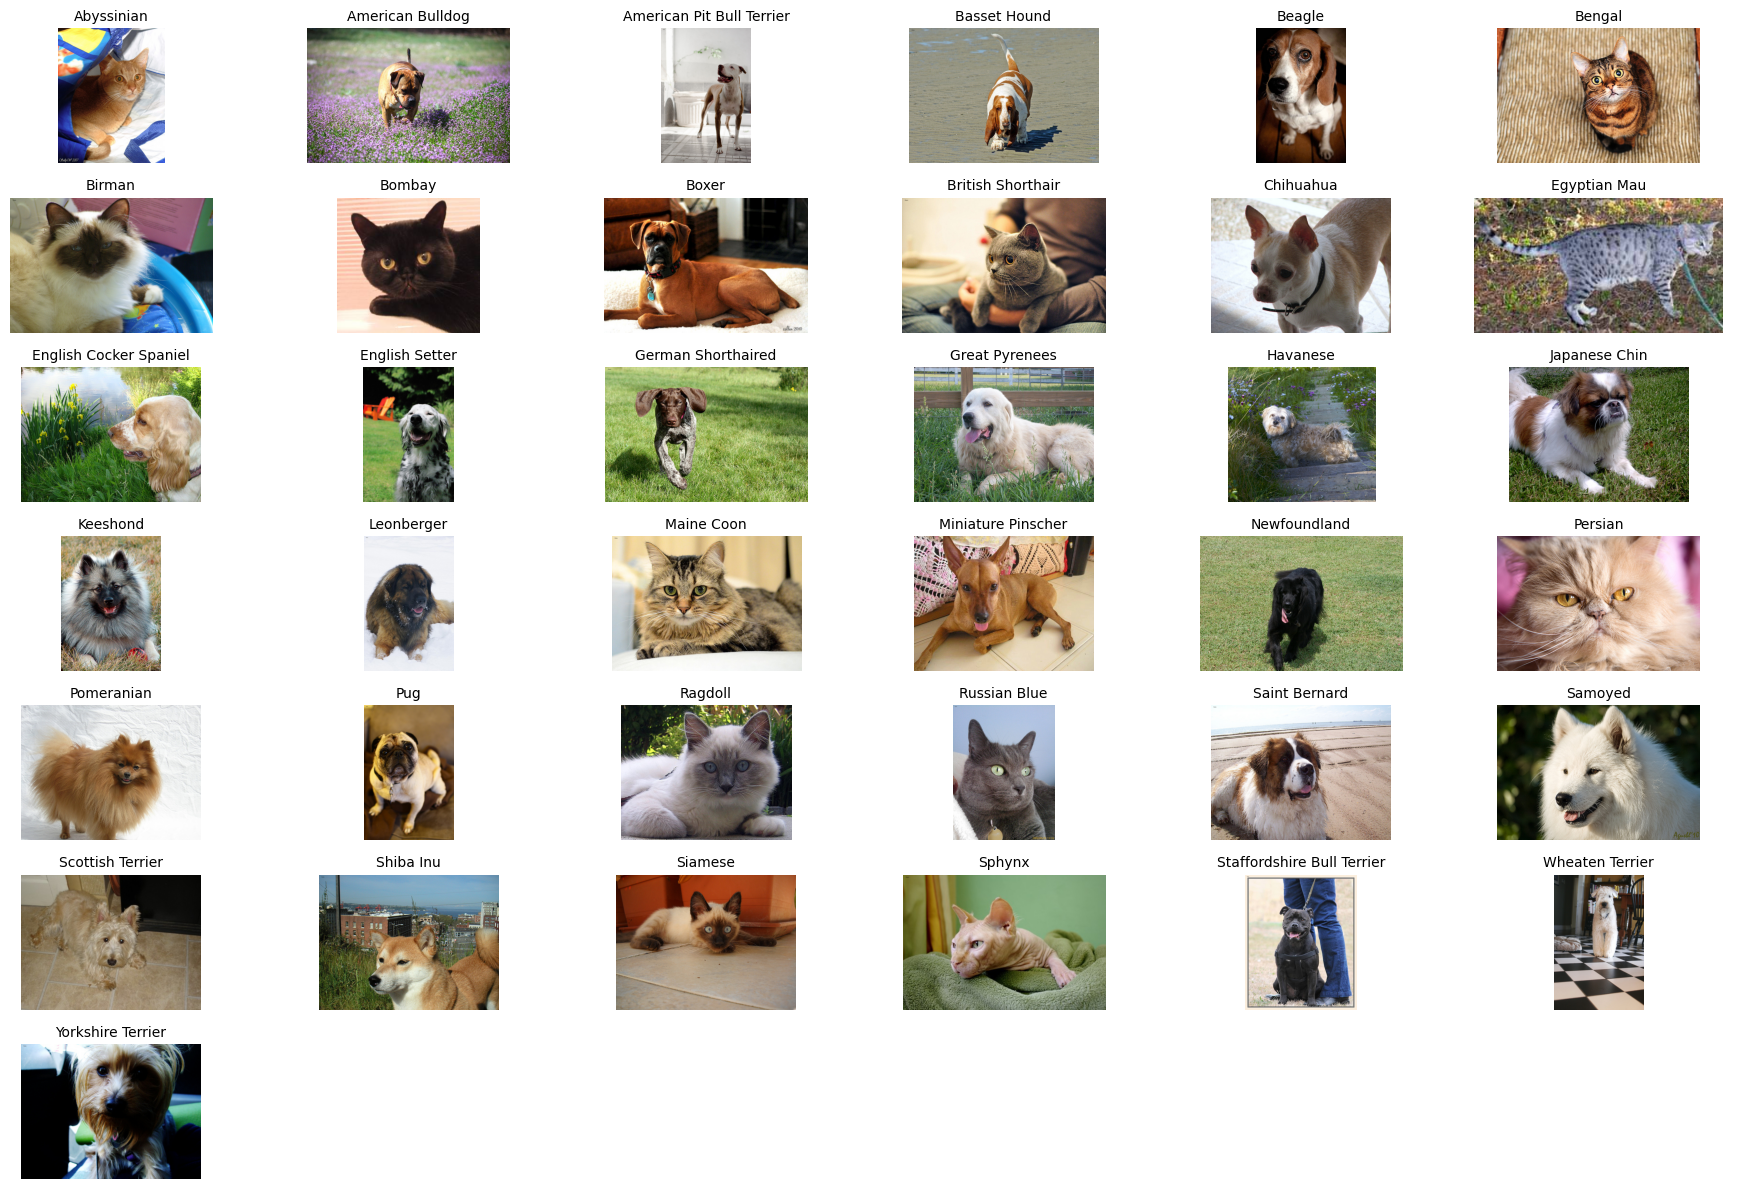

In [4]:
# visualise one image from each class

# get one sample per class
class_samples = {}

for img, label in dataset:
    if label not in class_samples:
        class_samples[label] = img
    if len(class_samples) == num_classes:
        break

# display in a grid
cols = 6
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

for idx, (class_idx, img) in enumerate(sorted(class_samples.items())):
    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(dataset.classes[class_idx], fontsize=10)
    ax.axis('off')

# hide empty subplots
for idx in range(len(class_samples), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# pre-processing operations

# splitting

seed = 42
train_size = 0.7
val_size = 0.15
test_size = 0.15
batch_size = 32
num_workers = 4 # change depending on GPU load


# transformation instructions

orb_transforms = v2.Compose([
    v2.Grayscale(num_output_channels=1), # conv grayscale
    v2.Resize((224, 224)), # resize to fixed size for ORB
])

train_transforms = v2.Compose([
    v2.Grayscale(num_output_channels=1), # conv grayscale 
    v2.RandomResizedCrop(size=(224, 224), antialias=True), # crop to fixed size and maintain qual
    v2.RandomHorizontalFlip(p=0.5), # flip images for better learning
    v2.ToImage(), # convert to tensor
    v2.ToDtype(torch.float32, scale=True), # conv pixel from int to float 
    v2.Normalize(mean=[0.5], std=[0.5]), # normalise using standard val
])

val_test_transforms = v2.Compose([
    v2.Grayscale(num_output_channels=1),
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5]),
])

In [6]:
# Do split operations

# convert to numpy for sklearn ops
indices = np.arange(data_size)
labels_arr = np.array(labels)

# split for test
sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
train_val_idx, test_idx = next(sss_test.split(indices, labels_arr))

# split remaining into train and val (70/15/15)

# find the relative size 
val_rel = val_size / (train_size + val_size)  # 0.15 / 0.85 (currently)

# split train_val into train and val using relative size
sss_val = StratifiedShuffleSplit(n_splits=1, test_size=val_rel, random_state=seed)
train_rel_idx, val_rel_idx = next(
    sss_val.split(train_val_idx, labels_arr[train_val_idx])
)

# Map relative indices back to original dataset indices
train_idx = train_val_idx[train_rel_idx]
val_idx = train_val_idx[val_rel_idx]

# verify splits
print(f"Total samples: {data_size}")
print(f"Train samples: {len(train_idx)}")
print(f"Validation samples: {len(val_idx)}")
print(f"Test samples: {len(test_idx)}")
print(f"Check total: {len(train_idx) + len(val_idx) + len(test_idx)}")

# optional sanity check: no overlap
assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)

# check maths
fifteen_pct = data_size / 100 * 15 
print(f"15 % of data: {fifteen_pct}")

Total samples: 3680
Train samples: 2576
Validation samples: 552
Test samples: 552
Check total: 3680
15 % of data: 552.0


In [7]:
# now splitting into the respective subsets and for ORB 

orb_base = datasets.OxfordIIITPet(root=data_path, transform=orb_transforms)
train_base = datasets.OxfordIIITPet(root=data_path, transform=train_transforms)
val_test_base = datasets.OxfordIIITPet(root=data_path, transform=val_test_transforms)

orb_ds = Subset(orb_base, train_idx) # only need to do ORB on the training set for now
train_ds = Subset(train_base, train_idx)
val_ds = Subset(val_test_base, val_idx)
test_ds = Subset(val_test_base, test_idx)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Feature Extraction using ORB
1. Detect keypoints using the ORB feature detector
2. Extract keypoints from grayscale images
3. Store descriptors for all training images for codebook generation

In [8]:
# initialise ORB detector
orb = cv.ORB_create()  # type: ignore[attr-defined]

# create storage
all_descrip = []

for img, label in orb_ds: # type: ignore (i can ignore..?)
    # orb_ds yields PIL grayscale images here, so convert to uint8 numpy array
    img_np = np.array(img, dtype=np.uint8)

    kp, des = orb.detectAndCompute(img_np, None)
    if des is not None:
        all_descrip.append(des)

print(f"Descriptor sets extracted: {len(all_descrip)} / {len(orb_ds)}")
print(all_descrip[0][0]) # show one descriptor

Descriptor sets extracted: 2576 / 2576
[ 75  48 123 224 101 221 249  83 107 249 116  10 157 159  86 160 239 185
 151 157 151  90 180 208 223 217 187 236 143 132 107 251]


# Codebook Generation and Representation
Construct visual vocabularies using Mini-Batch K-Means clustering with codebook sizes: [ K = 100, 300,
500 ]

For each value of K:
1. Train the codebook using descriptors from the training set only
2. Represent every image as a normalised histogram of visual words
3. Prepare histogram features for training validation and testing sets

In [9]:
# Stack training descriptors into one array for codebook
all_descrip_stacked = np.vstack(all_descrip)  # shape: (total_keypoints, 32)
print(f"Total training descriptors stacked: {all_descrip_stacked.shape}")

# Extract ORB descriptors + labels for val and test sets
orb_val_ds  = Subset(orb_base, val_idx)
orb_test_ds = Subset(orb_base, test_idx)

Total training descriptors stacked: (951578, 32)


In [10]:
# function for extracting features from orb set
def extract_orb_features(subset):
    """Extract ORB descriptors and labels from a dataset subset.
    Returns (desc_list, labels) where desc_list[i] may be None if no keypoints found."""
    orb_det = cv.ORB_create()  # type: ignore[attr-defined]
    desc_list, label_list = [], []
    for img, label in subset:
        img_np = np.array(img, dtype=np.uint8)
        _, des = orb_det.detectAndCompute(img_np, None)
        desc_list.append(des)
        label_list.append(label)
    return desc_list, np.array(label_list)

In [11]:
# Re-extract train to get per-image labels aligned with descriptors
print("Extracting train descriptors (with labels)...")
train_desc, train_labels_orb = extract_orb_features(orb_ds)
print("Extracting val descriptors...")
val_desc,   val_labels_orb   = extract_orb_features(orb_val_ds)
print("Extracting test descriptors...")
test_desc,  test_labels_orb  = extract_orb_features(orb_test_ds)

Extracting train descriptors (with labels)...
Extracting val descriptors...
Extracting test descriptors...


In [12]:
# normalised BoVW histogram
def build_histograms(desc_list, kmeans, K):
    hists = []
    for des in desc_list:
        if des is not None:
            words = kmeans.predict(des)                        # assign each keypoint to a visual word
            hist, _ = np.histogram(words, bins=K, range=(0, K))
            hist = hist / (hist.sum() + 1e-7)                 # normalise to frequency
        else:
            hist = np.zeros(K, dtype=np.float32)              # no keypoints → zero vector
        hists.append(hist)
    return np.array(hists, dtype=np.float32)

In [13]:
# train codebook and build histogram
codebook_sizes = [100, 300, 500]
bovw_data = {}

for K in codebook_sizes:
    print(f"\nFitting MiniBatchKMeans with K={K}...")
    kmeans = MiniBatchKMeans(n_clusters=K, random_state=seed, batch_size=1024, n_init=3)
    kmeans.fit(all_descrip_stacked)   # fit only on training descriptors

    X_train = build_histograms(train_desc, kmeans, K)
    X_val   = build_histograms(val_desc,   kmeans, K)
    X_test  = build_histograms(test_desc,  kmeans, K)

    bovw_data[K] = {
        'X_train': X_train, 'y_train': train_labels_orb,
        'X_val':   X_val,   'y_val':   val_labels_orb,
        'X_test':  X_test,  'y_test':  test_labels_orb,
        'kmeans':  kmeans,
    }
    print(f"  Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Fitting MiniBatchKMeans with K=100...
  Train: (2576, 100), Val: (552, 100), Test: (552, 100)

Fitting MiniBatchKMeans with K=300...
  Train: (2576, 300), Val: (552, 300), Test: (552, 300)

Fitting MiniBatchKMeans with K=500...
  Train: (2576, 500), Val: (552, 500), Test: (552, 500)


# Classification using Traditional Machine Learning 
For each codebook size:
1. Train a Gradient Boosting classifier on the training histogram features.
2. Evaluate the classifier on the validation set using:
- Accuracy
- Precision
- Recall
- F1-score
3. Compare results for K = 100, K = 300, and K = 500.
4. Select the best-performing vocabulary size.
5. Retrain the classifier using training and validation data.
6. Report final performance on the test set and include a confusion matrix.

In [14]:
# manual toggle
use_gpu = True

cuda_available = torch.cuda.is_available()
device = "cuda" if use_gpu and cuda_available else "cpu"

print("Manual GPU toggle:", use_gpu)
print("CUDA available:", cuda_available)
print("Selected device:", device)

if cuda_available:
    print("CUDA device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU.")

Manual GPU toggle: True
CUDA available: True
Selected device: cuda
CUDA device count: 1
Current device: 0
Device name: NVIDIA GeForce GTX 1650


In [ ]:
# tune boosted classifier for each codebook size

# use cuda capability
if device == "cuda":
    model = XGBClassifier(
        tree_method="hist",
        device="cuda",
        random_state=seed,
    )
else:
    model = XGBClassifier(
        tree_method="hist",
        device="cpu",
        random_state=seed,
    )

    # init search space
    param_space = {
        'n_estimators':  [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [2, 3, 4],
        'subsample':     [0.8, 1.0],
    }

# storage for best results
best_results = {}

for K, data in bovw_data.items():
    print(f"\n Tuning GBC for K={K}")
    X_trainer, Y_trainer = data['X_train'], data['y_train']
    X_valler, Y_valler = data['X_val'], data['y_val']

    search = RandomizedSearchCV(
        model,
        param_distributions=param_space,
        n_iter=10,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        random_state=seed,
        verbose=1
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        search.fit(X_trainer,Y_trainer)

    best_clf = search.best_estimator_
    val_preds = best_clf.predict(X_valler)
    val_acc = accuracy_score(Y_valler, val_preds)
    val_precision = precision_score(Y_valler, val_preds, average='macro', zero_division=0)
    val_recall = recall_score(Y_valler, val_preds, average='macro', zero_division=0)
    val_f1 = f1_score(Y_valler, val_preds, average='macro', zero_division=0)

    best_results[K] = {
        'params': search.best_params_,
        'cv_acc': search.best_score_,
        'val_acc': val_acc,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_f1': val_f1,
        'clf': best_clf,
    }
    print(f"  Best params   : {search.best_params_}")
    print(f"  CV accuracy   : {search.best_score_:.4f}")
    print(f"  Val accuracy  : {val_acc:.4f}")
    print(f"  Val precision : {val_precision:.4f}")
    print(f"  Val recall    : {val_recall:.4f}")
    print(f"  Val F1 score  : {val_f1:.4f}")


# Summary
print(f"\n{'K':>5} | {'CV acc':>8} | {'Val acc':>8} | {'Val prec':>8} | {'Val rec':>8} | {'Val F1':>8}")
for K, res in best_results.items():
    print(
        f"{K:>5} | {res['cv_acc']:>8.4f} | {res['val_acc']:>8.4f} | "
        f"{res['val_precision']:>8.4f} | {res['val_recall']:>8.4f} | {res['val_f1']:>8.4f}"
    )


 Tuning GBC for K=100
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  Best params   : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2}
  CV accuracy   : 0.0850
  Val accuracy  : 0.0833
  Val precision : 0.0760
  Val recall    : 0.0834
  Val F1 score  : 0.0781

 Tuning GBC for K=300
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  Best params   : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2}
  CV accuracy   : 0.0905
  Val accuracy  : 0.1123
  Val precision : 0.1041
  Val recall    : 0.1122
  Val F1 score  : 0.1055

 Tuning GBC for K=500
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  Best params   : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2}
  CV accuracy   : 0.0978
  Val accuracy  : 0.1087
  Val precision : 0.1110
  Val recall    : 0.1089
  Val F1 score  : 0.1058

    K |   CV acc |  Val acc | Val prec |  Val rec |   Val F1
  100 |   0.0850 |   0.

In [16]:
# report final test performance of best model

# choose best K by validation accuracy
best_val = max(v["val_acc"] for v in best_results.values())
candidate_K = [k for k, v in best_results.items() if v["val_acc"] == best_val]
best_K = min(candidate_K)

# retrain final model on train+val using the best params from tuning
best_params = best_results[best_K]["params"]
X_train_full = np.vstack([bovw_data[best_K]["X_train"], bovw_data[best_K]["X_val"]])
y_train_full = np.concatenate([bovw_data[best_K]["y_train"], bovw_data[best_K]["y_val"]])

# keep this final stage on CPU to avoid device-mismatch warning with numpy inputs
final_model = XGBClassifier(
    tree_method="hist",
    device="cpu",
    random_state=seed,
    **best_params,
)
final_model.fit(X_train_full, y_train_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cpu'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [17]:
# evaluate on test set
X_test = bovw_data[best_K]["X_test"]
y_test = bovw_data[best_K]["y_test"]
y_pred = final_model.predict(X_test)

print(f"Best K: {best_K}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("Classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

Best K: 300
Accuracy: 0.0960
Macro F1: 0.0928
Weighted F1: 0.0927
Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.17      0.20      0.18        15
           2       0.08      0.07      0.07        15
           3       0.11      0.13      0.12        15
           4       0.09      0.07      0.08        15
           5       0.20      0.27      0.23        15
           6       0.16      0.20      0.18        15
           7       0.33      0.36      0.34        14
           8       0.11      0.13      0.12        15
           9       0.18      0.13      0.15        15
          10       0.00      0.00      0.00        15
          11       0.00      0.00      0.00        14
          12       0.00      0.00      0.00        14
          13       0.00      0.00      0.00        15
          14       0.07      0.07      0.07        15
          15       0.12      0.13      0.12   

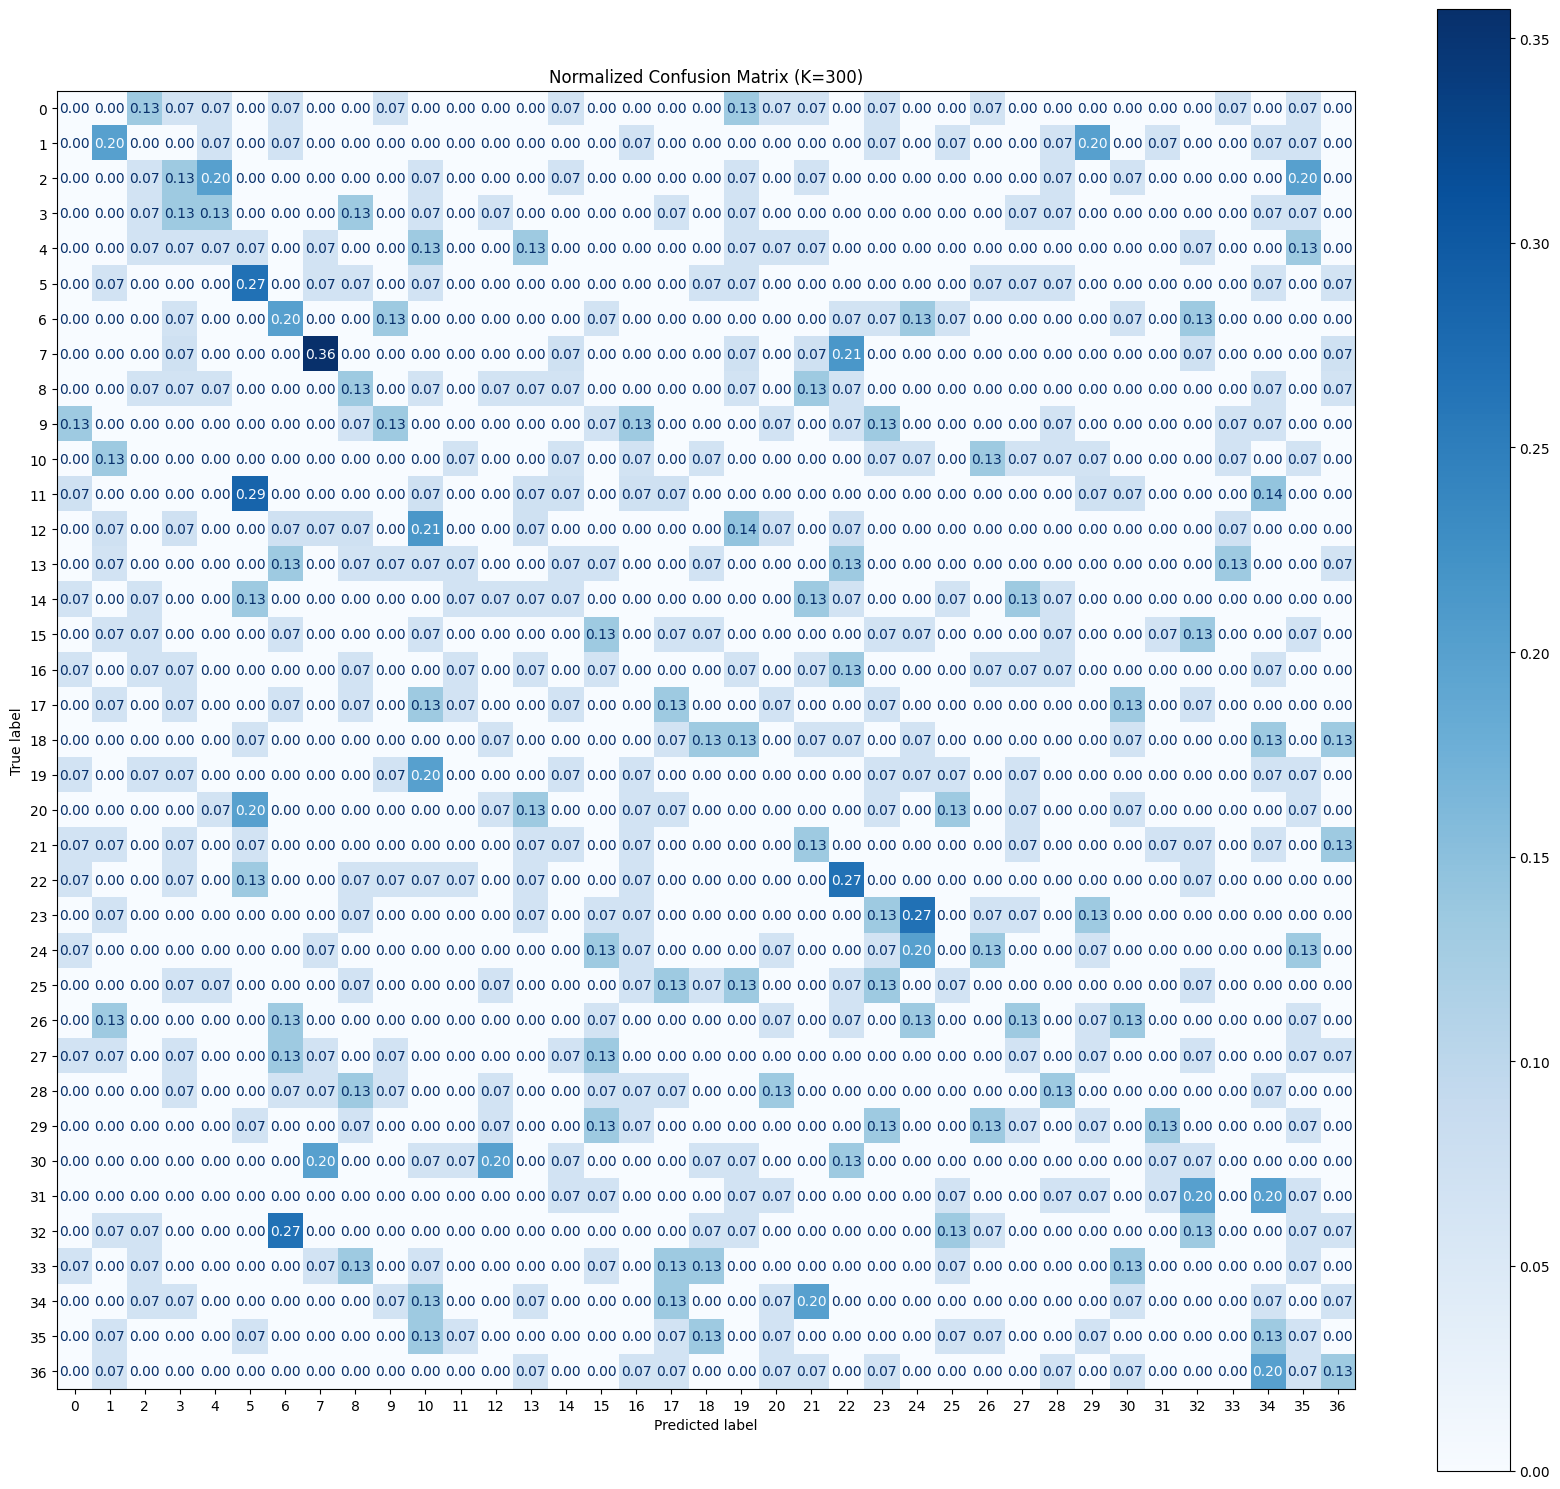

In [18]:
# normalized confusion matrix (easier to read with many classes)
cm = confusion_matrix(y_test, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(17, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=True)
ax.set_title(f"Normalized Confusion Matrix (K={best_K})")
plt.tight_layout()
plt.show()

# Deep Learning Classification + Data augmentation

### Classifications
1. Load a pre-trained DenseNet-121 model.
2. Replace the final classification layer for 10 classes.
3. Train (fine-tune) the network using the training dataset.
4. Evaluate performance on the validation and test sets using accuracy, precision, recall, and F1-score.

### Augment
1. Apply aerial-image appropriate augmentation:
- Rotation (90°, 180°, 270°)
- Horizontal flipping
- Vertical flipping
- Slight scaling
2. Retrain the DenseNet-121 model using the augmented dataset.
3. Compare performance with the non-augmented CNN mode

In [44]:
# import the model from pytorch
weights = models.DenseNet121_Weights.DEFAULT
model_dn121 = models.densenet121(weights=weights)

In [45]:
# customise the model for our dataset

# use all classes from the dataset (Oxford-IIIT Pet has 37)
num_classes = len(dataset.classes)

# replace the final classifier layer
in_features = model_dn121.classifier.in_features
model_dn121.classifier = nn.Linear(in_features, num_classes)

print(f"Using num_classes={num_classes}")
print(model_dn121.classifier)

Using num_classes=37
Linear(in_features=1024, out_features=37, bias=True)


In [46]:
# pytorch requires 3 channels for the CNN training so we have to re-define the transforms

# check shape first
img,label = train_ds[0]
print(img.shape)

torch.Size([1, 224, 224])


In [47]:
# helper: convert grayscale batch [N,1,H,W] -> [N,3,H,W]
def to_3_chan(imgs):
    if imgs.dim() == 4 and imgs.shape[1] == 1:
        imgs = imgs.repeat(1, 3, 1, 1)
    return imgs

# check transform on one batch
sample_imgs, _ = next(iter(train_loader))
print("before:", sample_imgs.shape)
print("after: ", to_3_chan(sample_imgs).shape)

before: torch.Size([32, 1, 224, 224])
after:  torch.Size([32, 3, 224, 224])


In [52]:
# CNN helpers used for both default and augmented runs

# function for making the model
def make_densenet(num_classes, device, freeze_backbone=True):
    # load the pretrained densenet
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

    # replace the final classifier layer for our dataset
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)

    # optional freeze of the feature extractor first
    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False

    # send model to cpu / cuda
    return model.to(device)


# helper to convert grayscale batches to 3 channels for densenet
def to_3_chan(imgs):
    # baseline pipeline uses grayscale tensors [N,1,H,W] but DenseNet expects 3 channels
    if imgs.dim() == 4 and imgs.shape[1] == 1:
        imgs = imgs.repeat(1, 3, 1, 1)
    return imgs


# helper for calculating metrics from predictions
def compute_metrics(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


# function for training the densenet model
def train_densenet(model, train_loader, val_loader, device, epochs=5, lr=1e-3):
    model = model.to(device)

    # define the loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    # store metrics from each epoch
    history = []

    for epoch in range(epochs):
        # training stage
        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        # do optimisation step
        for imgs, labels in train_loader:
            imgs = to_3_chan(imgs).to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * imgs.size(0)
            train_correct += (outputs.argmax(dim=1) == labels).sum().item()
            train_total += labels.size(0)

        # accum training metrics 
        train_loss = train_loss_sum / max(1, train_total)
        train_acc = train_correct / max(1, train_total)

        model.eval() # switch model to eval mode

        # tracking vars
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0
        val_y_true = []
        val_y_pred = []

        # without updating gradients iterate over val set
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = to_3_chan(imgs).to(device)
                labels = labels.to(device)

                outputs = model(imgs)
                vloss = criterion(outputs, labels)
                preds = outputs.argmax(dim=1)

                val_loss_sum += vloss.item() * imgs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                val_y_true.extend(labels.cpu().numpy())
                val_y_pred.extend(preds.cpu().numpy())

        # acccum validation metric
        val_loss = val_loss_sum / max(1, val_total)
        val_acc = val_correct / max(1, val_total)
        val_scores = compute_metrics(np.array(val_y_true), np.array(val_y_pred))

        # store training and eval metrics
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_precision": val_scores["precision"],
            "val_recall": val_scores["recall"],
            "val_f1": val_scores["f1"],
        })

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val Prec: {val_scores['precision']:.4f} | "
            f"Val Rec: {val_scores['recall']:.4f} | "
            f"Val F1: {val_scores['f1']:.4f}"
        )

    return model, history


# function for evaluating the densenet model
def evaluate_densenet(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    # no gradients needed in evaluation
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = to_3_chan(imgs).to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # return only the main metrics we want
    return {
        **compute_metrics(y_true, y_pred),
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [54]:
# do baseline run (task 5)
num_classes = len(dataset.classes)
baseline_epochs = 8
baseline_lr = 1e-4

# make and train the baseline model
baseline_model = make_densenet(num_classes=num_classes, device=device, freeze_backbone=True)
baseline_model, baseline_history = train_densenet(
    baseline_model,
    train_loader,
    val_loader,
    device=device,
    epochs=baseline_epochs,
    lr=baseline_lr,
)

# evaluate on validation and test sets
baseline_val_metrics = evaluate_densenet(baseline_model, val_loader, device=device)
baseline_metrics = evaluate_densenet(baseline_model, test_loader, device=device)

# print validation metrics first
print("\nBaseline validation metrics")
print(f"Accuracy:  {baseline_val_metrics['acc']:.4f}")
print(f"Precision: {baseline_val_metrics['precision']:.4f}")
print(f"Recall:    {baseline_val_metrics['recall']:.4f}")
print(f"F1 score:  {baseline_val_metrics['f1']:.4f}")

# print test metrics
print("\nBaseline test metrics")
print(f"Accuracy:  {baseline_metrics['acc']:.4f}")
print(f"Precision: {baseline_metrics['precision']:.4f}")
print(f"Recall:    {baseline_metrics['recall']:.4f}")
print(f"F1 score:  {baseline_metrics['f1']:.4f}")

Epoch 1/8 | Train Loss: 3.5028 | Train Acc: 0.0703 | Val Loss: 3.2880 | Val Acc: 0.1703 | Val Prec: 0.1920 | Val Rec: 0.1699 | Val F1: 0.1571
Epoch 2/8 | Train Loss: 3.1766 | Train Acc: 0.2446 | Val Loss: 2.9674 | Val Acc: 0.3533 | Val Prec: 0.3870 | Val Rec: 0.3530 | Val F1: 0.3356
Epoch 3/8 | Train Loss: 2.9022 | Train Acc: 0.3851 | Val Loss: 2.6795 | Val Acc: 0.4837 | Val Prec: 0.4973 | Val Rec: 0.4828 | Val F1: 0.4577
Epoch 4/8 | Train Loss: 2.6721 | Train Acc: 0.4790 | Val Loss: 2.4311 | Val Acc: 0.5580 | Val Prec: 0.6009 | Val Rec: 0.5578 | Val F1: 0.5426
Epoch 5/8 | Train Loss: 2.4846 | Train Acc: 0.5443 | Val Loss: 2.2399 | Val Acc: 0.6232 | Val Prec: 0.6526 | Val Rec: 0.6227 | Val F1: 0.6036
Epoch 6/8 | Train Loss: 2.2805 | Train Acc: 0.6068 | Val Loss: 2.0420 | Val Acc: 0.6649 | Val Prec: 0.6891 | Val Rec: 0.6641 | Val F1: 0.6541
Epoch 7/8 | Train Loss: 2.1279 | Train Acc: 0.6378 | Val Loss: 1.8897 | Val Acc: 0.6993 | Val Prec: 0.7183 | Val Rec: 0.6991 | Val F1: 0.6904
Epoch 

## Augmented Run (Same Pipeline)
Apply augmentation and reuse the same `train_densenet` / `evaluate_densenet` helpers for a fair comparison against baseline.

In [50]:
# special functions for the augmented runs

# loader factory for augmented 
def make_cnn_loaders(data_path, train_idx, val_idx, test_idx, train_tf, eval_tf, batch_size=32, num_workers=4):
    train_base = datasets.OxfordIIITPet(root=data_path, transform=train_tf)
    eval_base = datasets.OxfordIIITPet(root=data_path, transform=eval_tf)

    train_ds = Subset(train_base, train_idx)
    val_ds = Subset(eval_base, val_idx)
    test_ds = Subset(eval_base, test_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader


# transforms for training and eval
train_transforms_aug = v2.Compose([
    v2.Grayscale(num_output_channels=3),
    v2.Resize((224, 224), antialias=True),
    v2.RandomChoice([
        v2.RandomRotation((90, 90)),
        v2.RandomRotation((180, 180)),
        v2.RandomRotation((270, 270)),
    ]),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomAffine(degrees=0, scale=(0.95, 1.05)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transforms_aug = v2.Compose([
    v2.Grayscale(num_output_channels=3),
    v2.Resize((224, 224), antialias=True),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# load the augmented loaders
train_loader_aug, val_loader_aug, test_loader_aug = make_cnn_loaders(
    data_path,
    train_idx,
    val_idx,
    test_idx,
    train_transforms_aug,
    eval_transforms_aug,
    batch_size=batch_size,
    num_workers=num_workers,
)

# verify thru prints
print("Augmented loaders ready:")
print(f"Train batches: {len(train_loader_aug)} | Val batches: {len(val_loader_aug)} | Test batches: {len(test_loader_aug)}")

Augmented loaders ready:
Train batches: 81 | Val batches: 18 | Test batches: 18


In [55]:
# now do the training for second run

aug_epochs = 8
aug_lr = 1e-4

# define the second model based on new sets
aug_model = make_densenet(num_classes=num_classes, device=device, freeze_backbone=True)

# build and train
aug_model, aug_history = train_densenet(
    aug_model,
    train_loader_aug,
    val_loader_aug,
    device=device,
    epochs=aug_epochs,
    lr=aug_lr,
)

# eval on validation and test sets
aug_val_metrics = evaluate_densenet(aug_model, val_loader_aug, device=device)
aug_metrics = evaluate_densenet(aug_model, test_loader_aug, device=device)

# print the augmented validation results
print("\nAugmented validation metrics")
print(f"Accuracy:  {aug_val_metrics['acc']:.4f}")
print(f"Precision: {aug_val_metrics['precision']:.4f}")
print(f"Recall:    {aug_val_metrics['recall']:.4f}")
print(f"F1 score:  {aug_val_metrics['f1']:.4f}")

# print the augmented test results
print("\nAugmented test metrics")
print(f"Accuracy:  {aug_metrics['acc']:.4f}")
print(f"Precision: {aug_metrics['precision']:.4f}")
print(f"Recall:    {aug_metrics['recall']:.4f}")
print(f"F1 score:  {aug_metrics['f1']:.4f}")

# quick comparison with the baseline run
print("\nComparison (test split)")
print(f"Baseline accuracy:  {baseline_metrics['acc']:.4f}")
print(f"Augmented accuracy: {aug_metrics['acc']:.4f}")
print(f"Baseline precision:  {baseline_metrics['precision']:.4f}")
print(f"Augmented precision: {aug_metrics['precision']:.4f}")
print(f"Baseline recall:  {baseline_metrics['recall']:.4f}")
print(f"Augmented recall: {aug_metrics['recall']:.4f}")
print(f"Baseline F1:  {baseline_metrics['f1']:.4f}")
print(f"Augmented F1: {aug_metrics['f1']:.4f}")

Epoch 1/8 | Train Loss: 3.5637 | Train Acc: 0.0520 | Val Loss: 3.4092 | Val Acc: 0.1051 | Val Prec: 0.0902 | Val Rec: 0.1053 | Val F1: 0.0878
Epoch 2/8 | Train Loss: 3.3486 | Train Acc: 0.1277 | Val Loss: 3.2047 | Val Acc: 0.2065 | Val Prec: 0.2324 | Val Rec: 0.2066 | Val F1: 0.1909
Epoch 3/8 | Train Loss: 3.1583 | Train Acc: 0.2333 | Val Loss: 3.0084 | Val Acc: 0.3406 | Val Prec: 0.3799 | Val Rec: 0.3411 | Val F1: 0.3269
Epoch 4/8 | Train Loss: 2.9884 | Train Acc: 0.3331 | Val Loss: 2.8298 | Val Acc: 0.4312 | Val Prec: 0.4451 | Val Rec: 0.4310 | Val F1: 0.4156
Epoch 5/8 | Train Loss: 2.8439 | Train Acc: 0.3870 | Val Loss: 2.6773 | Val Acc: 0.4909 | Val Prec: 0.5313 | Val Rec: 0.4907 | Val F1: 0.4751
Epoch 6/8 | Train Loss: 2.6966 | Train Acc: 0.4449 | Val Loss: 2.5322 | Val Acc: 0.5598 | Val Prec: 0.5836 | Val Rec: 0.5598 | Val F1: 0.5463
Epoch 7/8 | Train Loss: 2.5767 | Train Acc: 0.4973 | Val Loss: 2.3999 | Val Acc: 0.5942 | Val Prec: 0.6206 | Val Rec: 0.5942 | Val F1: 0.5798
Epoch 